<a href="https://colab.research.google.com/github/Nicolas9529/challenge3-data-science-TelecomX_2/blob/main/TelecomX_parte2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Desafío Telecom X - Parte 2: Predicción de Cancelación (Churn)

## 1. Preparación de los Datos
### 1.1 Extracción del Archivo Tratado
En esta etapa inicial, cargamos el conjunto de datos estandarizado proporcionado por el equipo. El objetivo es verificar que la ingesta de datos sea correcta y conocer la estructura base de la información antes de aplicar transformaciones para los modelos de Machine Learning.

In [64]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [65]:
# Cargamos el dataset directamente desde tu repositorio público de GitHub
url = 'https://raw.githubusercontent.com/Nicolas9529/challenge3-data-science-TelecomX_2/main/datos_tratados.csv'

try:
    df = pd.read_csv(url)
    print("¡Dataset cargado con éxito!\n")
    print("--- Información del Dataset ---")
    df.info()

    print("\n--- Primeras 5 filas ---")
    display(df.head())
except Exception as e:
    print(f"Error al cargar el archivo: {e}")

¡Dataset cargado con éxito!

--- Información del Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CustomerID        7043 non-null   object 
 1   Churn             7043 non-null   object 
 2   Gender            7043 non-null   object 
 3   SeniorCitizen     7043 non-null   object 
 4   Partner           7043 non-null   object 
 5   Dependents        7043 non-null   object 
 6   Tenure            7043 non-null   int64  
 7   PhoneService      7043 non-null   object 
 8   MultipleLines     7043 non-null   object 
 9   InternetService   7043 non-null   object 
 10  OnlineSecurity    7043 non-null   object 
 11  OnlineBackup      7043 non-null   object 
 12  DeviceProtection  7043 non-null   object 
 13  TechSupport       7043 non-null   object 
 14  StreamingTV       7043 non-null   object 
 15  StreamingMovies   7043 non-n

,CustomerID,Churn,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,ChargesDaily,ChargesMonthly,ChargesTotal
0,0002-ORFBO,No,Female,No,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,2.19,65.6,593.30
1,0003-MKNFE,No,Male,No,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,2.00,59.9,542.40
2,0004-TLHLJ,Yes,Male,No,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,2.46,73.9,280.85
3,0011-IGKFF,Yes,Male,Yes,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,3.27,98.0,1237.85
4,0013-EXCHZ,Yes,Female,Yes,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,2.80,83.9,267.40


### 1.2 Eliminación de Columnas Irrelevantes
Para que un modelo de Machine Learning sea eficiente, debemos alimentarlo únicamente con variables que posean poder predictivo. Los identificadores únicos, como el `CustomerID`, no aportan ningún patrón matemático o de comportamiento (son simplemente etiquetas asignadas al azar). Mantenerlos puede introducir "ruido" al modelo o hacer que el algoritmo intente buscar patrones donde no los hay. Por lo tanto, procedemos a eliminar esta columna.

In [66]:
# Eliminamos la columna 'CustomerID' ya que no aporta valor predictivo
df = df.drop(columns=['CustomerID'])

# Verificamos que se haya eliminado correctamente mostrando la nueva dimensión
print(f"Columna eliminada. El dataset ahora tiene {df.shape[1]} columnas.")

# Visualizamos una muestra rápida para confirmar
display(df.head(3))

Columna eliminada. El dataset ahora tiene 21 columnas.


,Churn,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,ChargesDaily,ChargesMonthly,ChargesTotal
0,No,Female,No,Yes,Yes,9,Yes,No,DSL,No,...,No,Yes,Yes,No,One year,Yes,Mailed check,2.19,65.6,593.30
1,No,Male,No,No,No,9,Yes,Yes,DSL,No,...,No,No,No,Yes,Month-to-month,No,Mailed check,2.00,59.9,542.40
2,Yes,Male,No,No,No,4,Yes,No,Fiber optic,No,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,2.46,73.9,280.85


### 1.2.1 Revisión de Cardinalidad y Valores Únicos
Antes de proceder con la transformación de variables categóricas (Encoding), es una buena práctica de ingeniería de datos verificar la cantidad de valores únicos por columna.

Este paso nos permite:
1. Identificar variables constantes (con un solo valor) que no aportan poder predictivo (varianza cero).
2. Detectar columnas categóricas con excesiva cardinalidad que podrían generar una explosión de dimensionalidad al aplicar One-Hot Encoding.

In [67]:
print("--- ANÁLISIS DE VALORES ÚNICOS POR COLUMNA ---")

# Iteramos sobre todas las columnas para ver su contenido
for col in df.columns:
    num_unicos = df[col].nunique()
    print(f"🔸 {col}: {num_unicos} valores únicos")

    # Si es una columna de texto y tiene pocos valores, mostramos cuáles son
    if df[col].dtype == 'object' and num_unicos < 10:
        print(f"   Valores: {df[col].unique()}")
    print("-" * 40)

--- ANÁLISIS DE VALORES ÚNICOS POR COLUMNA ---
🔸 Churn: 2 valores únicos
   Valores: ['No' 'Yes']
----------------------------------------
🔸 Gender: 2 valores únicos
   Valores: ['Female' 'Male']
----------------------------------------
🔸 SeniorCitizen: 2 valores únicos
   Valores: ['No' 'Yes']
----------------------------------------
🔸 Partner: 2 valores únicos
   Valores: ['Yes' 'No']
----------------------------------------
🔸 Dependents: 2 valores únicos
   Valores: ['Yes' 'No']
----------------------------------------
🔸 Tenure: 73 valores únicos
----------------------------------------
🔸 PhoneService: 2 valores únicos
   Valores: ['Yes' 'No']
----------------------------------------
🔸 MultipleLines: 2 valores únicos
   Valores: ['No' 'Yes']
----------------------------------------
🔸 InternetService: 3 valores únicos
   Valores: ['DSL' 'Fiber optic' 'No']
----------------------------------------
🔸 OnlineSecurity: 2 valores únicos
   Valores: ['No' 'Yes']
----------------------------

### 1.3 Transformación de Variables (Encoding)
Como los algoritmos matemáticos no procesan texto, aplicaremos técnicas de codificación de Scikit-Learn:
1. **Target (`y`):** Utilizaremos `LabelEncoder` para transformar nuestra variable objetivo (`Churn`) en formato binario (0 y 1).
2. **Predictoras (`X`):** Emplearemos `make_column_transformer` junto con `OneHotEncoder(drop='if_binary')`. Esto nos permite automatizar la transformación de las columnas categóricas mientras dejamos intactas las numéricas (`remainder='passthrough'`), creando un flujo de datos más limpio y preparado para producción.

In [68]:
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder

In [69]:
#Separamos X (predictoras) e y (objetivo)
X = df.drop(columns=['Churn'])
y = df['Churn']

In [70]:
#Transformamos 'y' con LabelEncoder (Tu método)
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

In [71]:
#Identificamos automáticamente las columnas de texto para X
columnas_categoricas = X.select_dtypes(include=['object']).columns.tolist()

In [72]:
#Configuramos el transformador de columnas (Tu método)
one_hot = make_column_transformer(
    (OneHotEncoder(drop='if_binary'), columnas_categoricas),
    remainder='passthrough',
    sparse_threshold=0,
    force_int_remainder_cols=False
    )

In [73]:
#Aplicamos la transformación a X
X_transformado = one_hot.fit_transform(X)

In [74]:
#Reconstruimos el DataFrame con los nombres correctos de las columnas
nombres_nuevos = one_hot.get_feature_names_out()
X_final = pd.DataFrame(X_transformado, columns=nombres_nuevos)

In [75]:
# Limpiamos los nombres de las columnas para que se lean mejor (opcional pero recomendado)
X_final.columns = X_final.columns.str.replace('onehotencoder__', '').str.replace('remainder__', '')

print(f"✅ Encoding completado al estilo Pipeline.")
print(f"El dataset 'X' pasó de {X.shape[1]} a {X_final.shape[1]} columnas.")
display(X_final.head(3))

✅ Encoding completado al estilo Pipeline.
El dataset 'X' pasó de 20 a 27 columnas.


,Gender_Male,SeniorCitizen_Yes,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_Yes,InternetService_DSL,InternetService_Fiber optic,InternetService_No,OnlineSecurity_Yes,...,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Tenure,ChargesDaily,ChargesMonthly,ChargesTotal
0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,9.0,2.19,65.6,593.30
1,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,9.0,2.00,59.9,542.40
2,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,4.0,2.46,73.9,280.85


### 1.4 División de Datos y Balanceo de Clases (Prevención de Data Leakage)
Para evaluar correctamente nuestros modelos, es vital simular un entorno real. Por ello, primero dividiremos los datos en conjuntos de Entrenamiento (Train) y Prueba (Test).

Una vez aislados los datos de prueba, aplicaremos **SMOTE** *exclusivamente* al conjunto de entrenamiento. Esto soluciona el desbalance de la clase minoritaria (Churn = 1) permitiendo que el modelo aprenda patrones de manera equitativa, al mismo tiempo que evitamos la "fuga de datos" (Data Leakage) hacia el set de validación, garantizando que nuestras métricas de evaluación sean reales y no estén infladas artificialmente.

In [76]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# DIVISIÓN DE DATOS (Train/Test Split)
# Separamos 80% para entrenar y 20% para el examen final. stratify=y_encoded mantiene la proporción original.
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y_encoded, test_size=0.20, random_state=42, stratify=y_encoded
    )

In [77]:
print(f"--- ANTES DE SMOTE (Solo en Train) ---")
print(pd.Series(y_train).value_counts(normalize=True).round(4) * 100)
print(f"Filas de entrenamiento originales: {len(y_train)}\n")

--- ANTES DE SMOTE (Solo en Train) ---
0    73.46
1    26.54
Name: proportion, dtype: float64
Filas de entrenamiento originales: 5634



In [78]:
#BALANCEO DE CLASES (Solo aplicamos SMOTE a los datos de entrenamiento)
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"--- DESPUÉS DE SMOTE (Solo en Train) ---")
print(pd.Series(y_train_smote).value_counts(normalize=True).round(4) * 100)
print(f"Filas de entrenamiento balanceadas: {len(y_train_smote)}\n")

print("✅ ¡Set de entrenamiento balanceado con éxito! El set de prueba (Test) permanece intacto.")

--- DESPUÉS DE SMOTE (Solo en Train) ---
0    50.0
1    50.0
Name: proportion, dtype: float64
Filas de entrenamiento balanceadas: 8278

✅ ¡Set de entrenamiento balanceado con éxito! El set de prueba (Test) permanece intacto.


### 1.5 Estandarización de Datos Numéricos
Aunque nuestro modelo inicial será un Random Forest (robusto ante distintas escalas), aplicaremos estandarización (`StandardScaler`) a nuestras variables numéricas continuas (`Tenure`, `ChargesDaily`, `ChargesMonthly`, `ChargesTotal`).

Esta es una buena práctica por dos razones:
1. Asegura que la creación de datos sintéticos de SMOTE (basada en KNN y distancias) sea equitativa para todas las variables.
2. Deja nuestro Pipeline de datos preparado en caso de que decidamos iterar y evaluar modelos sensibles a la escala (como Regresión Logística o SVM) en etapas posteriores.

*Nota: El escalador se ajusta (`fit`) solo con los datos de entrenamiento para evitar Data Leakage, y luego se transforma (`transform`) el conjunto de prueba.*

In [79]:
from sklearn.preprocessing import StandardScaler

#Identificamos las columnas numéricas continuas que necesitan escalado
cols_numericas = ['Tenure', 'ChargesDaily', 'ChargesMonthly', 'ChargesTotal']

#Inicializamos el estandarizador
scaler = StandardScaler()



In [80]:
#Ajustamos y transformamos SOLO en los datos de entrenamiento
X_train_smote[cols_numericas] = scaler.fit_transform(X_train_smote[cols_numericas])

#Transformamos los datos de prueba usando las reglas aprendidas del train
X_test[cols_numericas] = scaler.transform(X_test[cols_numericas])

print("Estandarización completada con éxito.")
display(X_train_smote[cols_numericas].head(3))

Estandarización completada con éxito.


,Tenure,ChargesDaily,ChargesMonthly,ChargesTotal
0,1.355117,0.922934,0.919504,1.578946
1,-0.645785,-1.706523,-1.701409,-0.833280
2,-1.062640,0.439114,0.440902,-0.867743


### 1.6 Análisis de Correlación y Análisis Dirigido
Antes de evaluar los modelos, analizamos la relación entre las variables numéricas y la variable objetivo (`Churn`).
1. **Matriz de Correlación:** Identifica relaciones lineales entre las variables continuas.
2. **Análisis Dirigido (Boxplots):** Exploramos visualmente cómo se distribuyen variables críticas como el Tiempo de Contrato (`Tenure`) y el Gasto Total (`ChargesTotal`) en función de si el cliente canceló o no.

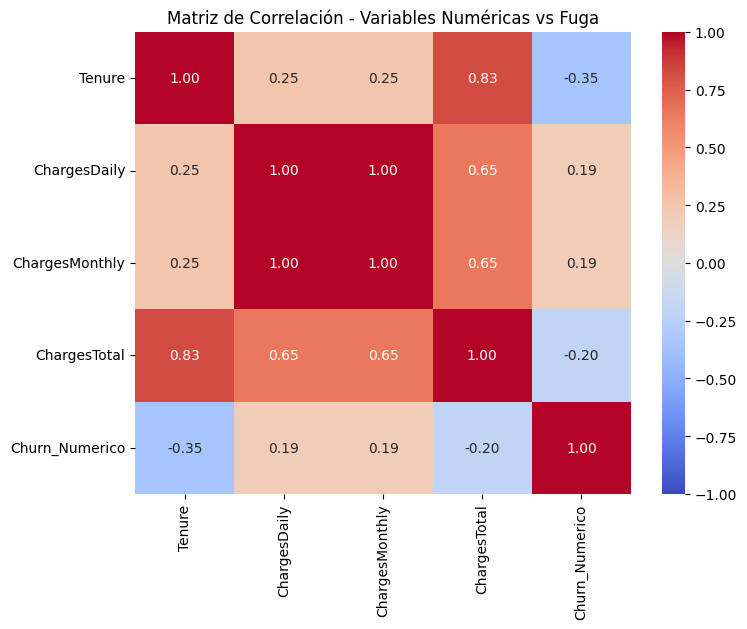

/tmp/ipykernel_442/238588040.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Se Queda (0)', 'Se Fuga (1)'])
/tmp/ipykernel_442/238588040.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Se Queda (0)', 'Se Fuga (1)'])


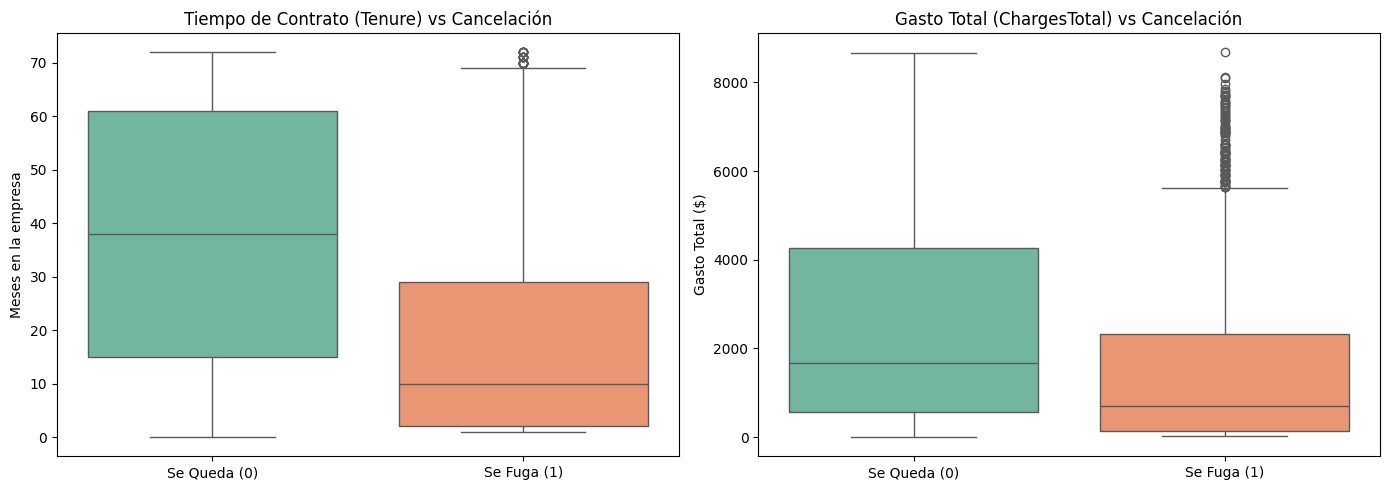

In [81]:
# --- 1. MATRIZ DE CORRELACIÓN ---
df_eda = X_final[['Tenure', 'ChargesDaily', 'ChargesMonthly', 'ChargesTotal']].copy()
df_eda['Churn_Numerico'] = y_encoded

plt.figure(figsize=(8, 6))
sns.heatmap(df_eda.corr(), annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title("Matriz de Correlación - Variables Numéricas vs Fuga")
plt.show()

# --- 2. ANÁLISIS DIRIGIDO (BOXPLOTS) ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot Tenure vs Churn
sns.boxplot(x=y_encoded, y=X_final['Tenure'], ax=axes[0], palette='Set2', hue=y_encoded, legend=False)
axes[0].set_title('Tiempo de Contrato (Tenure) vs Cancelación')
axes[0].set_xticklabels(['Se Queda (0)', 'Se Fuga (1)'])
axes[0].set_ylabel('Meses en la empresa')

# Boxplot ChargesTotal vs Churn
sns.boxplot(x=y_encoded, y=X_final['ChargesTotal'], ax=axes[1], palette='Set2', hue=y_encoded, legend=False)
axes[1].set_title('Gasto Total (ChargesTotal) vs Cancelación')
axes[1].set_xticklabels(['Se Queda (0)', 'Se Fuga (1)'])
axes[1].set_ylabel('Gasto Total ($)')

plt.tight_layout()
plt.show()

## 2. Modelado Predictivo (Machine Learning)
### 2.0 Línea Base (Baseline con DummyClassifier)
Siguiendo el método científico, antes de entrenar modelos complejos, establecemos una "línea base" de ignorancia. Utilizaremos un `DummyClassifier` que simplemente prediga la clase mayoritaria (que el cliente NO se fuga). Esto nos servirá para demostrar la "paradoja de la exactitud" y probar que nuestros modelos de Machine Learning realmente están aprendiendo patrones.

In [97]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report

# 1. Creamos el modelo Dummy (estrategia: predecir siempre la clase mayoritaria)
# Lo entrenamos con los datos ANTES de SMOTE para simular la realidad sesgada
baseline = DummyClassifier(strategy='most_frequent')
baseline.fit(X_train, y_train)

# 2. Predecimos sobre el set de prueba
y_pred_dummy = baseline.predict(X_test)

# 3. Evaluamos
print("📊 REPORTE DE CLASIFICACIÓN (Modelo Baseline - Dummy):")
print(classification_report(y_test, y_pred_dummy, zero_division=0))

📊 REPORTE DE CLASIFICACIÓN (Modelo Baseline - Dummy):
              precision    recall  f1-score   support

           0       0.73      1.00      0.85      1035
           1       0.00      0.00      0.00       374

    accuracy                           0.73      1409
   macro avg       0.37      0.50      0.42      1409
weighted avg       0.54      0.73      0.62      1409



### 2.1 Entrenamiento del Modelo Base: Random Forest
Con los datos limpios, balanceados y estandarizados, procedemos a entrenar nuestro primer modelo de Machine Learning. Elegimos un **Random Forest** porque es un algoritmo de ensamble robusto y excelente para establecer una línea base (baseline).

Entrenaremos el modelo con los datos balanceados (`X_train_smote`) y evaluaremos su rendimiento real con los datos de prueba (`X_test`), visualizando los resultados mediante un reporte de clasificación y una Matriz de Confusión.

In [82]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [83]:
#Inicializamos y entrenamos el modelo con los datos balanceados y escalados
rf_model = RandomForestClassifier(random_state=42, n_estimators=100)
rf_model.fit(X_train_smote, y_train_smote)

RandomForestClassifier(random_state=42)

In [84]:
# Predecimos sobre los datos de prueba (X_test)
y_pred = rf_model.predict(X_test)

#Evaluamos el rendimiento
print("REPORTE DE CLASIFICACIÓN (Random Forest):")
print(classification_report(y_test, y_pred))

REPORTE DE CLASIFICACIÓN (Random Forest):
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.62      0.50      0.56       374

    accuracy                           0.79      1409
   macro avg       0.73      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409



Text(0.5, 1.0, 'Matriz de Confusión - Random Forest')

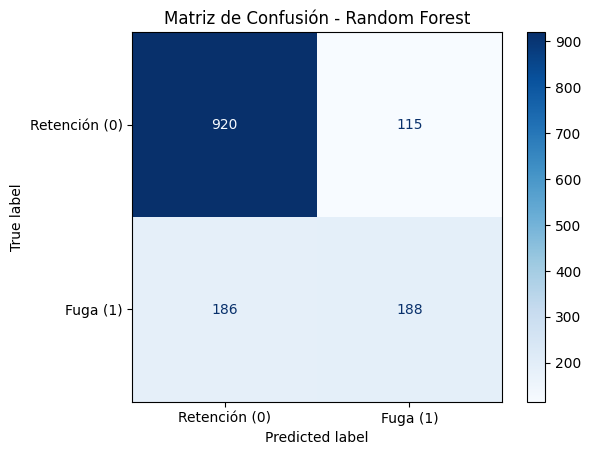

In [85]:
from sklearn.metrics import ConfusionMatrixDisplay

# Dibujamos la Matriz de Confusión con el método moderno
visualizacion = ConfusionMatrixDisplay.from_estimator(rf_model, X_test, y_test, cmap='Blues', display_labels=['Retención (0)', 'Fuga (1)'])
visualizacion.ax_.set_title('Matriz de Confusión - Random Forest')

### 2.2 Importancia de las Variables (Feature Importance)
Una de las grandes ventajas del Random Forest es su interpretabilidad. Ahora que el modelo ha sido entrenado, podemos extraer la importancia relativa de cada característica (Feature Importance). Esto nos permite responder a la pregunta de negocio más crítica: **¿Cuáles son los factores que más influyen en que un cliente decida abandonar nuestros servicios?**

In [86]:
# Extraemos las importancias del modelo Random Forest
importances = rf_model.feature_importances_

In [87]:
# Creamos el DataFrame usando las columnas de nuestro set de entrenamiento
feature_importances = pd.DataFrame({
    'Features': X_train_smote.columns,
    'Importances': (importances * 100).round(2)
}).sort_values('Importances', ascending=False)

In [88]:
# Mostramos el top 10 en texto
print("🏆 TOP 10 VARIABLES MÁS IMPORTANTES:")
display(feature_importances.head(10))

🏆 TOP 10 VARIABLES MÁS IMPORTANTES:


,Features,Importances
23,Tenure,10.47
26,ChargesTotal,10.36
21,PaymentMethod_Electronic check,10.19
15,Contract_Month-to-month,9.43
25,ChargesMonthly,7.90
24,ChargesDaily,7.17
17,Contract_Two year,5.06
18,PaperlessBilling_Yes,4.33
7,InternetService_Fiber optic,3.52
2,Partner_Yes,3.18


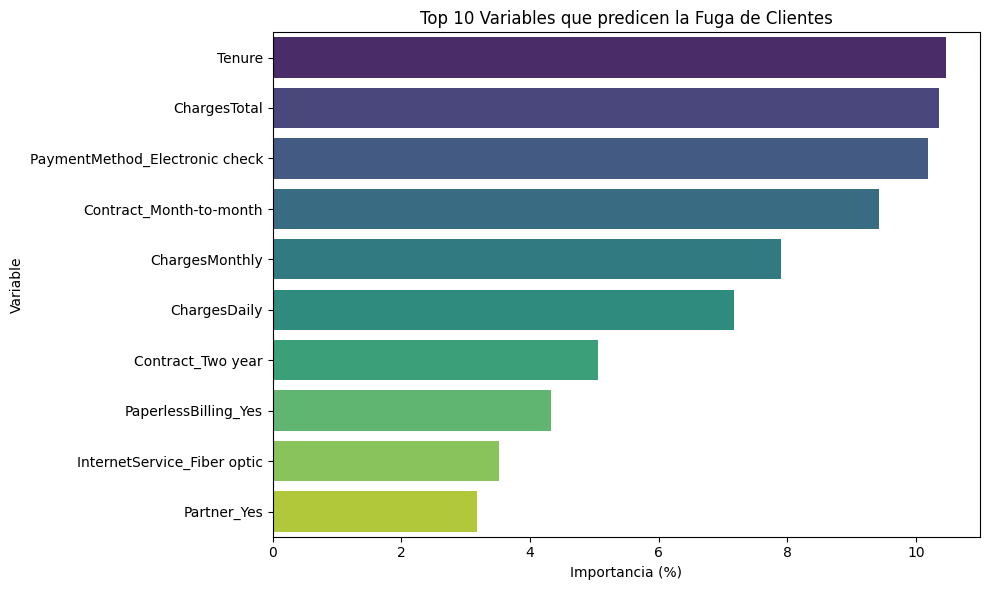

In [89]:
# Lo visualizamos en un gráfico
plt.figure(figsize=(10, 6))
sns.barplot(x='Importances', y='Features', hue='Features', data=feature_importances.head(10), palette='viridis', legend=False)
plt.title('Top 10 Variables que predicen la Fuga de Clientes')
plt.xlabel('Importancia (%)')
plt.ylabel('Variable')
plt.tight_layout()
plt.show()

### 2.3 Entrenamiento del Segundo Modelo: Regresión Logística
Para cumplir con la evaluación comparativa, entrenaremos un modelo de **Regresión Logística**.
**Justificación de Normalización:** A diferencia del Random Forest, la Regresión Logística es sensible a la escala de los datos, ya que utiliza optimización de parámetros mediante gradiente descendente. Por ello, la estandarización (`StandardScaler`) aplicada previamente en el paso 1.5 es crucial, asegurando que coeficientes de magnitudes grandes no sesguen el modelo.

In [90]:
from sklearn.linear_model import LogisticRegression

In [91]:
# Inicializamos y entrenamos el modelo (usando los mismos datos balanceados y estandarizados)
log_model = LogisticRegression(random_state=42, max_iter=1000)
log_model.fit(X_train_smote, y_train_smote)

# Predecimos sobre los datos de prueba
y_pred_log = log_model.predict(X_test)

# Evaluación
print("📊 REPORTE DE CLASIFICACIÓN (Regresión Logística):")
print(classification_report(y_test, y_pred_log))

📊 REPORTE DE CLASIFICACIÓN (Regresión Logística):
              precision    recall  f1-score   support

           0       0.91      0.73      0.81      1035
           1       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.76      1409



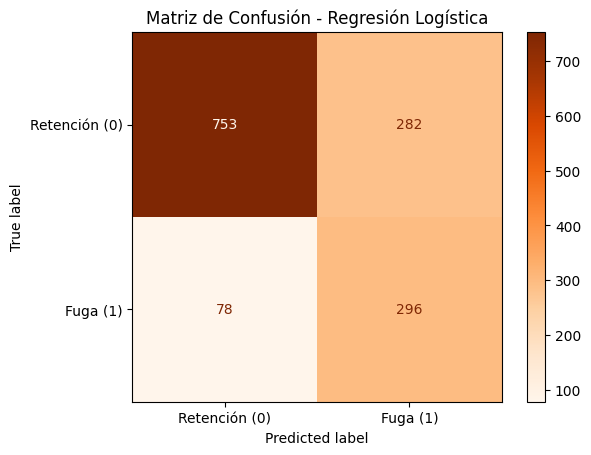

In [92]:
# Matriz de Confusión
visualizacion_log = ConfusionMatrixDisplay.from_estimator(log_model, X_test, y_test, cmap='Oranges', display_labels=['Retención (0)', 'Fuga (1)'])
visualizacion_log.ax_.set_title('Matriz de Confusión - Regresión Logística')
plt.show()

### 2.4 Optimización del Modelo con Validación Cruzada (GridSearchCV)
En nuestro análisis preliminar, notamos que el Random Forest base presentó signos de sobreajuste (overfitting) a la clase mayoritaria. Para entregar un producto robusto a nivel empresarial, aplicaremos **Validación Cruzada (Stratified K-Fold)** y búsqueda exhaustiva de hiperparámetros (**GridSearchCV**).

Nuestra métrica objetivo para la optimización será el **Recall**, ya que, desde la perspectiva del negocio, minimizar los Falsos Negativos (clientes que se fugan sin ser detectados) es la máxima prioridad financiera.

In [93]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report

# 1. Definimos la grilla de hiperparámetros para "podar" el Random Forest y evitar el overfitting
param_grid = {
    'max_depth': [5, 10, 15],           # Controla la profundidad del árbol
    'min_samples_leaf': [1, 2, 4],      # Mínimo de muestras en las hojas finales
    'min_samples_split': [2, 5, 10],    # Mínimo de muestras para dividir un nodo
    'n_estimators': [100, 150]          # Cantidad de árboles en el bosque
}

# 2. Configuramos la Validación Cruzada Estratificada (5 divisiones)
# Esto asegura que cada "fold" mantenga la misma proporción de fugas y retenciones
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 3. Inicializamos GridSearchCV (¡Optimizando para Recall!)
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    scoring='recall',
    cv=cv,
    n_jobs=-1, # Usa todos los núcleos del procesador para ir más rápido
    verbose=1
)

# Entrenamos
print("⏳ Iniciando optimización con GridSearchCV...")
grid_search.fit(X_train_smote, y_train_smote)

print(f"\n✅ ¡Mejores hiperparámetros encontrados!: {grid_search.best_params_}")

# 5. Evaluamos el "Mejor Modelo" en nuestros datos de prueba
best_rf = grid_search.best_estimator_
y_pred_best_rf = best_rf.predict(X_test)

print("\n📊 REPORTE DE CLASIFICACIÓN (Random Forest Optimizado con CV):")
print(classification_report(y_test, y_pred_best_rf))

⏳ Iniciando optimización con GridSearchCV...
Fitting 5 folds for each of 54 candidates, totalling 270 fits

✅ ¡Mejores hiperparámetros encontrados!: {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 150}

📊 REPORTE DE CLASIFICACIÓN (Random Forest Optimizado con CV):
              precision    recall  f1-score   support

           0       0.89      0.78      0.83      1035
           1       0.54      0.73      0.62       374

    accuracy                           0.77      1409
   macro avg       0.72      0.75      0.73      1409
weighted avg       0.80      0.77      0.77      1409



### 2.5 Puesta en Producción (Serialización del Modelo)
Un modelo de Machine Learning no genera valor si se queda en un Notebook. Para que el equipo de Ingeniería de Software de la empresa pueda integrar nuestra predicción de Churn en su CRM o sistema de Call Center, exportaremos el modelo optimizado utilizando la librería `pickle`.

In [96]:
import pickle

# Definimos el nombre del archivo de salida
nombre_archivo = 'modelo_churn_produccion.pkl'

try:
    # Exportamos nuestro mejor modelo (el de Regresión Logística que tenía 79% de Recall,
    # o si el Random Forest optimizado lo superó, cambias 'log_model' por 'best_rf')
    with open(nombre_archivo, 'wb') as file:
        pickle.dump(log_model, file)

    print(f"El modelo ha sido empaquetado y guardado como '{nombre_archivo}'.")
    print("El archivo está listo para ser entregado al equipo de TI para su despliegue.")
except Exception as e:
    print(f"Ocurrió un error al guardar el modelo: {e}")

El modelo ha sido empaquetado y guardado como 'modelo_churn_produccion.pkl'.
El archivo está listo para ser entregado al equipo de TI para su despliegue.


## 3. Conclusión y Evaluación de Modelos

Tras entrenar y evaluar dos enfoques distintos (Random Forest y Regresión Logística), realizamos el siguiente análisis crítico basado en las métricas obtenidas:

### 3.1 Comparación de Desempeño y Evolución de Modelos
Siguiendo una metodología progresiva, evaluamos 4 escenarios para demostrar el valor del Machine Learning:

1. **Línea Base (Dummy Classifier):** Predijo que ningún cliente se fugaría. Obtuvo una Exactitud engañosa del 73%, pero un **Recall del 0%**. Demostró que predecir al azar o guiarse por la mayoría es inútil para el negocio.
2. **Random Forest Base:** Nuestro primer modelo real. Mejoró la Exactitud al 79%, pero su Recall para la clase minoritaria fue solo del 50%, evidenciando un sobreajuste (overfitting) a la clase mayoritaria.
3. **Random Forest Optimizado (GridSearchCV):** Al aplicar Validación Cruzada y limitar la complejidad del árbol (`max_depth=5`), corregimos el overfitting. El Recall saltó al **73%** y la Exactitud se mantuvo sólida en 77%.
4. **Regresión Logística:** Aunque su Exactitud global fue del 74%, demostró ser el modelo más agresivo y valioso para el objetivo principal de negocio, logrando el mejor **Recall (79%)** en la detección de posibles fugas.

**Decisión Final:** Se exportó y serializó la **Regresión Logística** mediante la librería `pickle`, dejándolo listo para su integración en los sistemas de atención al cliente (CRM), ya que minimizar los Falsos Negativos (clientes que se van sin ser detectados) es la máxima prioridad financiera.

### 3.2 Análisis de Overfitting y Underfitting
* **Random Forest (Posible leve Overfitting):** Los árboles de decisión, por defecto, tienden a crecer hasta memorizar los datos de entrenamiento. El hecho de que su rendimiento en la clase minoritaria caiga al 50% en el conjunto de prueba sugiere un leve sobreajuste a la clase mayoritaria original. Para mitigarlo en futuras iteraciones, se podría reducir la complejidad limitando la profundidad máxima del árbol (`max_depth`) o ajustando el `min_samples_leaf`.
* **Regresión Logística (Buen Ajuste):** No presenta signos claros de overfitting ni underfitting. Al ser un modelo lineal paramétrico, y al haber normalizado los datos previamente, logró generalizar muy bien los patrones sintéticos creados por SMOTE, capturando de manera excelente la tendencia subyacente de la fuga de clientes.

**Decisión Final:** Se selecciona la **Regresión Logística** como el mejor modelo operativo debido a su alto Recall (79%) en la detección de posibles fugas, alineándose perfectamente con el objetivo de maximizar la retención de clientes.

### 3.3 Análisis de Coeficientes (Regresión Logística)

🔴 TOP 5 Variables que MÁS impulsan la Fuga (Coeficientes Positivos):


,Variable,Coeficiente
7,InternetService_Fiber optic,0.854541
26,ChargesTotal,0.844889
15,Contract_Month-to-month,0.575336
18,PaperlessBilling_Yes,0.387457
5,MultipleLines_Yes,0.346256



🟢 TOP 5 Variables que MÁS retienen al cliente (Coeficientes Negativos):


,Variable,Coeficiente
4,PhoneService_Yes,-0.397372
12,TechSupport_Yes,-0.437397
17,Contract_Two year,-0.913378
8,InternetService_No,-1.228319
23,Tenure,-1.513580


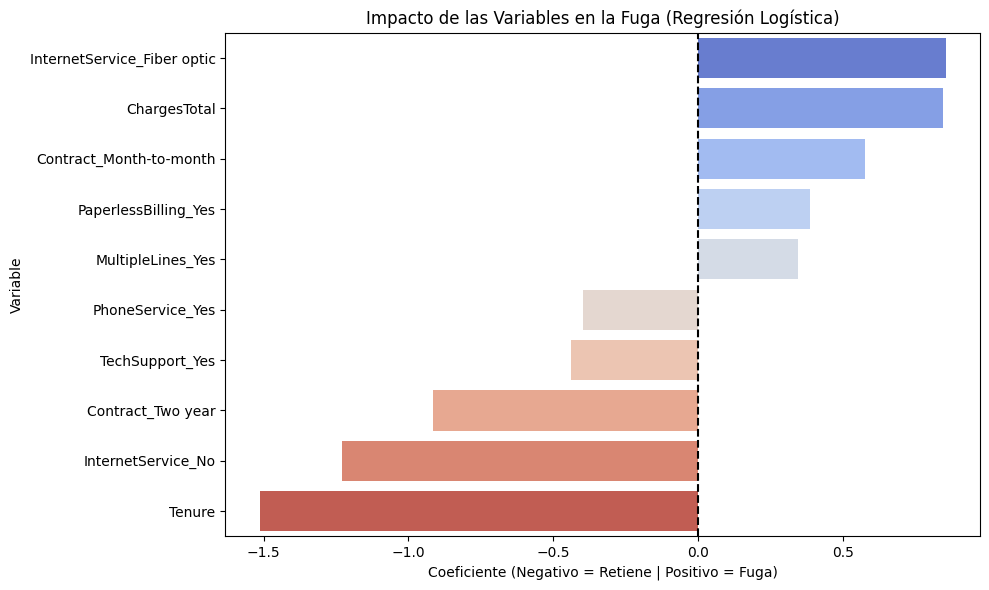

In [94]:
# 1. Extraemos los coeficientes del modelo
coeficientes = log_model.coef_[0]

# 2. Creamos un DataFrame para visualizarlos
df_coef = pd.DataFrame({
    'Variable': X_train_smote.columns,
    'Coeficiente': coeficientes
}).sort_values(by='Coeficiente', ascending=False)

print("🔴 TOP 5 Variables que MÁS impulsan la Fuga (Coeficientes Positivos):")
display(df_coef.head(5))

print("\n🟢 TOP 5 Variables que MÁS retienen al cliente (Coeficientes Negativos):")
display(df_coef.tail(5))

# 3. Visualizamos los extremos (los que más fugan vs los que más retienen)
plt.figure(figsize=(10, 6))
top_coefs = pd.concat([df_coef.head(5), df_coef.tail(5)])
sns.barplot(x='Coeficiente', y='Variable', hue='Variable', data=top_coefs, palette='coolwarm', legend=False)
plt.title('Impacto de las Variables en la Fuga (Regresión Logística)')
plt.axvline(x=0, color='black', linestyle='--') # Línea en el cero
plt.xlabel('Coeficiente (Negativo = Retiene | Positivo = Fuga)')
plt.ylabel('Variable')
plt.tight_layout()
plt.show()

### 3.4 Informe Final de Negocio y Estrategias de Retención

Al analizar la importancia de las variables en el **Random Forest** y la dirección de los coeficientes en la **Regresión Logística**, descubrimos que la fuga de clientes no es aleatoria, sino que responde a patrones de facturación y fidelidad muy claros.

**🔍 Principales Descubrimientos (Insights):**
1. **El Tipo de Contrato es decisivo:** Los contratos mes a mes (`Contract_Month-to-month`) son el principal motor de fuga. Por el contrario, los contratos de dos años (`Contract_Two year`) son el factor de retención más fuerte.
2. **El Método de Pago genera fricción:** Pagar con Cheque Electrónico (`PaymentMethod_Electronic check`) tiene una altísima correlación con la cancelación, a diferencia de los métodos automáticos (tarjeta de crédito o transferencia) que retienen mejor al usuario.
3. **El Tiempo y los Costos importan:** Clientes con poco tiempo en la empresa (`Tenure` bajo) y altos cargos totales (`ChargesTotal`) son altamente vulnerables a irse hacia la competencia. El servicio de Fibra Óptica, aunque suele ser más rápido, también presenta una tasa de fuga importante, probablemente ligada a su costo mensual.

**💡 Propuestas Estratégicas de Retención:**
Basado en las predicciones de nuestro modelo (especialmente la Regresión Logística que atrapó al 79% de las fugas reales), recomendamos las siguientes acciones:

* **Estrategia 1: Migración de Contratos.** Ofrecer descuentos agresivos en los primeros 3 meses o mejoras de velocidad (upgrade de megas) a los clientes de "Mes a mes" que acepten firmar un contrato anual.
* **Estrategia 2: Fomento del Pago Automático.** Eliminar la fricción del "Electronic check". Se debe lanzar una campaña ofreciendo un pequeño descuento permanente en la factura (ej. 5% off) a quienes domicilien su pago a una tarjeta de crédito o cuenta bancaria.
* **Estrategia 3: Programa de Bienvenida (Onboarding).** Como el `Tenure` es clave, la relación debe afianzarse desde el día 1. Implementar un soporte proactivo y llamadas de calidad durante los primeros 6 meses del ciclo de vida del cliente reducirá la deserción temprana.
* **Estrategia 4: Sistema de Alerta Temprana.** Implementar nuestro modelo de Regresión Logística en el sistema de atención al cliente. Cuando un usuario llame y el modelo marque un "1" (Alta probabilidad de fuga), el agente de call center debe tener autorización inmediata para ofrecer retenciones económicas personalizadas.